<a href="https://colab.research.google.com/github/Haladar-Alert/DZ_math/blob/main/%D0%B4%D0%B74_%D1%81%D0%B0%D0%BC%D0%BE%D0%BB%D0%B5%D1%82%D0%B8%D0%BA%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

file_path = '/content/drive/MyDrive/datasets/forest_dataset.csv'

flight_data_path = '/content/drive/MyDrive/datasets/flights.csv'
airport_data_path = '/content/drive/MyDrive/datasets/airports.csv'

# Установим стиль для графиков для лучшей читаемости (можно выполнить позже, но лучше сразу)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7) # Размер графиков по умолчанию
plt.rcParams['font.size'] = 12 # Размер шрифта по умолчанию


Mounted at /content/drive


In [11]:
try:
    # Загружаем данные о рейсах. low_memory=False может помочь с большими файлами со смешанными типами
    df_flights = pd.read_csv(flight_data_path, low_memory=False)
    print("--- Данные о рейсах (df_flights) ---")
    print("Файл успешно загружен.")
    print("\nИнформация о DataFrame (df_flights.info()):")
    df_flights.info()
    print("\nПервые 5 строк (df_flights.head()):")
    print(df_flights.head())
    print("\nРазмер DataFrame (rows, columns):", df_flights.shape)

    print("\n" + "="*50 + "\n") # Разделитель для читаемости

    # Загружаем данные об аэропортах
    df_airports = pd.read_csv(airport_data_path)
    print("--- Данные об аэропортах (df_airports) ---")
    print("Файл успешно загружен.")
    print("\nИнформация о DataFrame (df_airports.info()):")
    df_airports.info()
    print("\nПервые 5 строк (df_airports.head()):")
    print(df_airports.head())
    print("\nРазмер DataFrame (rows, columns):", df_airports.shape)

except FileNotFoundError:
    print(f"ОШИБКА: Один из файлов не найден. Проверь пути:")
    print(f"Рейсы: '{flight_data_path}'")
    print(f"Аэропорты: '{airport_data_path}'")
    print("Убедись, что Google Drive смонтирован и файлы существуют.")
except Exception as e:
    print(f"ОШИБКА: Произошла проблема при загрузке данных: {e}")

--- Данные о рейсах (df_flights) ---
Файл успешно загружен.

Информация о DataFrame (df_flights.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  


In [13]:
initial_rows = len(df_flights)
df_flights = df_flights[~df_flights['ORIGIN_AIRPORT'].astype(str).str.match(r'^\d+$')]
df_flights = df_flights[~df_flights['DESTINATION_AIRPORT'].astype(str).str.match(r'^\d+$')]
rows_after_cleaning = len(df_flights)
if initial_rows != rows_after_cleaning:
     print(f"Удалено {initial_rows - rows_after_cleaning} строк с числовыми кодами аэропортов.")
else:
    print("Числовые коды аэропортов не найдены или уже были отфильтрованы.")

# 2. Создание колонки FLIGHT_DATE
try:
    df_flights['FLIGHT_DATE'] = pd.to_datetime(df_flights[['YEAR', 'MONTH', 'DAY']])
    print("Колонка 'FLIGHT_DATE' успешно создана.")
except Exception as e:
    print(f"Ошибка при создании FLIGHT_DATE: {e}")

def format_time(time_series):
    original_nan_mask = time_series.isna()
    time_series_filled = time_series.fillna(-1).astype(int)

    time_str = time_series_filled.astype(str).str.zfill(4)
    time_str[original_nan_mask] = None

    valid_time_str = time_str.dropna()
    time_formatted = pd.Series(index=time_str.index, dtype=object)
    time_formatted.loc[valid_time_str.index] = valid_time_str.str[:2] + ':' + valid_time_str.str[2:]

    datetime_obj = pd.to_datetime(time_formatted.dropna(), format='%H:%M', errors='coerce')

    result_series = pd.Series(index=time_str.index, dtype='datetime64[ns]')
    result_series.loc[datetime_obj.index] = datetime_obj
    return result_series.dt.time

time_columns_to_format = ['SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'WHEELS_OFF', 'WHEELS_ON', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME']

print("\nПреобразование колонок времени:")
for col in time_columns_to_format:
    if col in df_flights.columns:
        new_col_name = col + '_TIME'
        try:
            df_flights[new_col_name] = format_time(df_flights[col])
            valid_count = df_flights[new_col_name].notna().sum()
            original_count = df_flights[col].notna().sum()
            print(f" - Колонка '{col}' преобразована в '{new_col_name}' (время). Успешно: {valid_count}/{original_count} значений.")
            invalid_time_mask = df_flights[col].notna() & df_flights[new_col_name].isna()
            if invalid_time_mask.sum() > 0:
                 print(f"   -> Найдено {invalid_time_mask.sum()} некорректных значений времени в '{col}', которые стали NaT. Они будут обработаны как пропуски.")


        except Exception as e:
            print(f"   - Ошибка при обработке колонки '{col}': {e}")
    else:
        print(f" - Колонка '{col}' не найдена в df_flights.")

duration_columns = ['DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAXI_IN', 'ARRIVAL_DELAY',
                    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

print("\nПроверка и преобразование числовых колонок:")
for col in duration_columns:
    if col in df_flights.columns:
        df_flights[col] = pd.to_numeric(df_flights[col], errors='coerce')
        nan_count = df_flights[col].isna().sum()
        print(f" - Колонка '{col}' проверена/преобразована в числовой тип. Количество NaN: {nan_count}")
    else:
         print(f" - Колонка '{col}' не найдена.")


print("\n--- Информация о df_flights после преобразований (первые 5 колонок и новые временные) ---")
cols_to_show = ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_DATE'] + [col + '_TIME' for col in time_columns_to_format if col + '_TIME' in df_flights.columns]
print(df_flights[cols_to_show].info())

print("\n--- Пример данных с новыми колонками времени ---")
print(df_flights[cols_to_show].head())




Числовые коды аэропортов не найдены или уже были отфильтрованы.
Колонка 'FLIGHT_DATE' успешно создана.

Преобразование колонок времени:
 - Колонка 'SCHEDULED_DEPARTURE' преобразована в 'SCHEDULED_DEPARTURE_TIME' (время). Успешно: 5332914/5332914 значений.
 - Колонка 'DEPARTURE_TIME' преобразована в 'DEPARTURE_TIME_TIME' (время). Успешно: 5248625/5249100 значений.
   -> Найдено 475 некорректных значений времени в 'DEPARTURE_TIME', которые стали NaT. Они будут обработаны как пропуски.
 - Колонка 'WHEELS_OFF' преобразована в 'WHEELS_OFF_TIME' (время). Успешно: 5245634/5246302 значений.
   -> Найдено 668 некорректных значений времени в 'WHEELS_OFF', которые стали NaT. Они будут обработаны как пропуски.
 - Колонка 'WHEELS_ON' преобразована в 'WHEELS_ON_TIME' (время). Успешно: 5241093/5242972 значений.
   -> Найдено 1879 некорректных значений времени в 'WHEELS_ON', которые стали NaT. Они будут обработаны как пропуски.
 - Колонка 'SCHEDULED_ARRIVAL' преобразована в 'SCHEDULED_ARRIVAL_TIME' (в

In [14]:
airports_info = df_airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE']].copy()
airports_info.rename(columns={'AIRPORT': 'AIRPORT_NAME'}, inplace=True)


df_flights = pd.merge(
    df_flights,
    airports_info,
    left_on='ORIGIN_AIRPORT',
    right_on='IATA_CODE',
    how='left' # 'left' сохранит все рейсы, даже если аэропорт не найден в df_airports
)

df_flights.rename(columns={'IATA_CODE': 'IATA_CODE_ORIG',
                           'AIRPORT_NAME': 'AIRPORT_NAME_ORIG',
                           'CITY': 'CITY_ORIG',
                           'STATE': 'STATE_ORIG'}, inplace=True)


df_flights = pd.merge(
    df_flights,
    airports_info,
    left_on='DESTINATION_AIRPORT',
    right_on='IATA_CODE',
    how='left'
)
df_flights.rename(columns={'IATA_CODE': 'IATA_CODE_DEST',
                           'AIRPORT_NAME': 'AIRPORT_NAME_DEST',
                           'CITY': 'CITY_DEST',
                           'STATE': 'STATE_DEST'}, inplace=True)



# Проверим результат
print("\n--- Информация о df_flights после добавления данных аэропортов ---")
cols_to_show = ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
                'IATA_CODE_ORIG', 'AIRPORT_NAME_ORIG', 'CITY_ORIG', 'STATE_ORIG',
                'IATA_CODE_DEST', 'AIRPORT_NAME_DEST', 'CITY_DEST', 'STATE_DEST']
df_flights[cols_to_show].info()

print("\n--- Пример данных с названиями аэропортов ---")
print(df_flights[cols_to_show].head())

# Проверим, сколько рейсов не нашли соответствия в справочнике аэропортов
missing_orig = df_flights['AIRPORT_NAME_ORIG'].isna().sum()
missing_dest = df_flights['AIRPORT_NAME_DEST'].isna().sum()
print(f"\nКоличество рейсов без информации об аэропорте отправления: {missing_orig}")
print(f"Количество рейсов без информации об аэропорте назначения: {missing_dest}")




--- Информация о df_flights после добавления данных аэропортов ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5332914 entries, 0 to 5332913
Data columns (total 10 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   ORIGIN_AIRPORT       object
 1   DESTINATION_AIRPORT  object
 2   IATA_CODE_ORIG       object
 3   AIRPORT_NAME_ORIG    object
 4   CITY_ORIG            object
 5   STATE_ORIG           object
 6   IATA_CODE_DEST       object
 7   AIRPORT_NAME_DEST    object
 8   CITY_DEST            object
 9   STATE_DEST           object
dtypes: object(10)
memory usage: 406.9+ MB

--- Пример данных с названиями аэропортов ---
  ORIGIN_AIRPORT DESTINATION_AIRPORT IATA_CODE_ORIG  \
0            ANC                 SEA            ANC   
1            LAX                 PBI            LAX   
2            SFO                 CLT            SFO   
3            LAX                 MIA            LAX   
4            SEA                 ANC            SEA   

  

In [16]:
delay_type_columns = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

df_flights_delay_filled = df_flights.copy()
df_flights_delay_filled[delay_type_columns] = df_flights_delay_filled[delay_type_columns].fillna(0)

# Группируем по аэропорту отправления
airport_stats = df_flights_delay_filled.groupby(['ORIGIN_AIRPORT', 'AIRPORT_NAME_ORIG', 'CITY_ORIG', 'STATE_ORIG']).agg(
    total_flights=('FLIGHT_NUMBER', 'count'), # Общее количество рейсов
    avg_dep_delay=('DEPARTURE_DELAY', 'mean'), # Средняя задержка вылета
    median_dep_delay=('DEPARTURE_DELAY', 'median'), # Медианная задержка вылета
    avg_arr_delay=('ARRIVAL_DELAY', 'mean'), # Средняя задержка прилета (для рейсов из этого аэропорта)
    median_arr_delay=('ARRIVAL_DELAY', 'median'), # Медианная задержка прилета

    # Процент рейсов с задержкой вылета > 15 минут
    pct_dep_delayed_15min=('DEPARTURE_DELAY', lambda x: (x > 15).mean() * 100),

    # Процент рейсов с задержкой прилета > 15 минут
    pct_arr_delayed_15min=('ARRIVAL_DELAY', lambda x: (x > 15).mean() * 100),

    # Средние значения по типам задержек (используем df с заполненными нулями)
    avg_air_system_delay=(delay_type_columns[0], 'mean'),
    avg_security_delay=(delay_type_columns[1], 'mean'),
    avg_airline_delay=(delay_type_columns[2], 'mean'),
    avg_late_aircraft_delay=(delay_type_columns[3], 'mean'),
    avg_weather_delay=(delay_type_columns[4], 'mean')
).reset_index()

print(f"Рассчитаны метрики для {len(airport_stats)} аэропортов.")

# Шаг 2: Фильтрация и определение "худших" аэропортов
min_flights_threshold = 1000

significant_airports = airport_stats[airport_stats['total_flights'] >= min_flights_threshold].copy()
print(f"Оставлено {len(significant_airports)} аэропортов с >= {min_flights_threshold} рейсами для дальнейшего анализа.")


worst_by_avg_delay = significant_airports.nlargest(15, 'avg_dep_delay')

worst_by_pct_delay = significant_airports.nlargest(15, 'pct_dep_delayed_15min')

print("\n--- Топ-15 аэропортов по СРЕДНЕЙ задержке вылета (avg_dep_delay) ---")
print(worst_by_avg_delay[['AIRPORT_NAME_ORIG', 'CITY_ORIG', 'total_flights', 'avg_dep_delay', 'pct_dep_delayed_15min']])

print("\n--- Топ-15 аэропортов по ПРОЦЕНТУ рейсов с задержкой вылета > 15 мин (pct_dep_delayed_15min) ---")
print(worst_by_pct_delay[['AIRPORT_NAME_ORIG', 'CITY_ORIG', 'total_flights', 'avg_dep_delay', 'pct_dep_delayed_15min']])



Рассчитаны метрики для 322 аэропортов.
Оставлено 225 аэропортов с >= 1000 рейсами для дальнейшего анализа.

--- Топ-15 аэропортов по СРЕДНЕЙ задержке вылета (avg_dep_delay) ---
                              AIRPORT_NAME_ORIG        CITY_ORIG  \
19                  Aspen-Pitkin County Airport            Aspen   
97                Eagle County Regional Airport            Eagle   
73                    Columbia Regional Airport         Columbia   
305                      Trenton Mercer Airport          Trenton   
228        Chicago O'Hare International Airport          Chicago   
106        Newark Liberty International Airport           Newark   
51   Baltimore-Washington International Airport        Baltimore   
182     LaGuardia Airport (Marine Air Terminal)         New York   
195        Chicago Midway International Airport          Chicago   
59            Charlottesville-Albemarle Airport  Charlottesville   
149     Washington Dulles International Airport        Chantilly   
203    

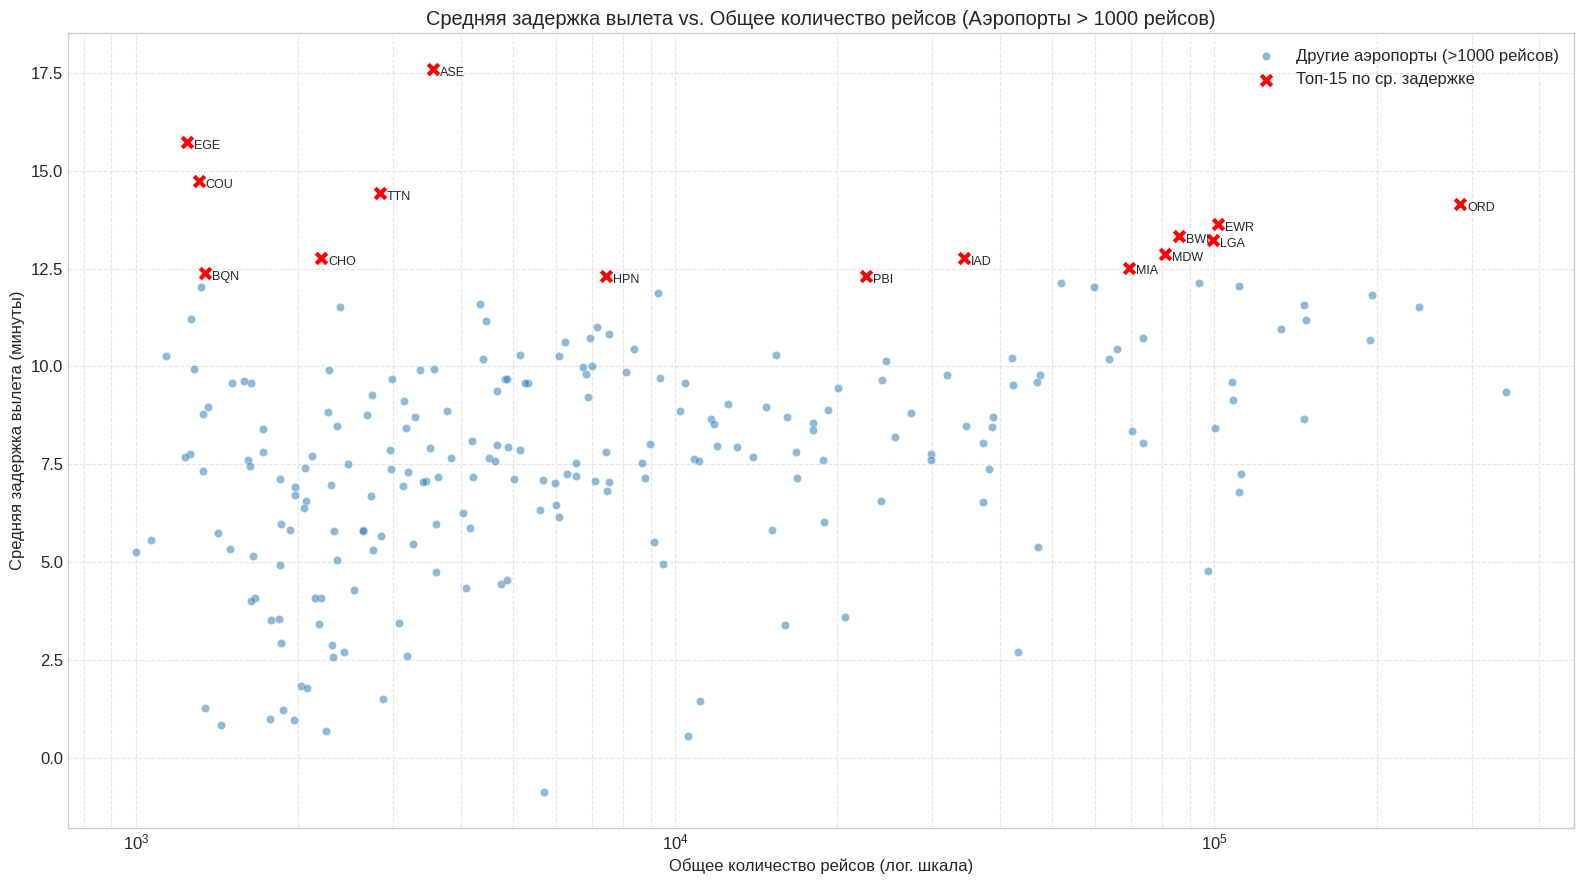

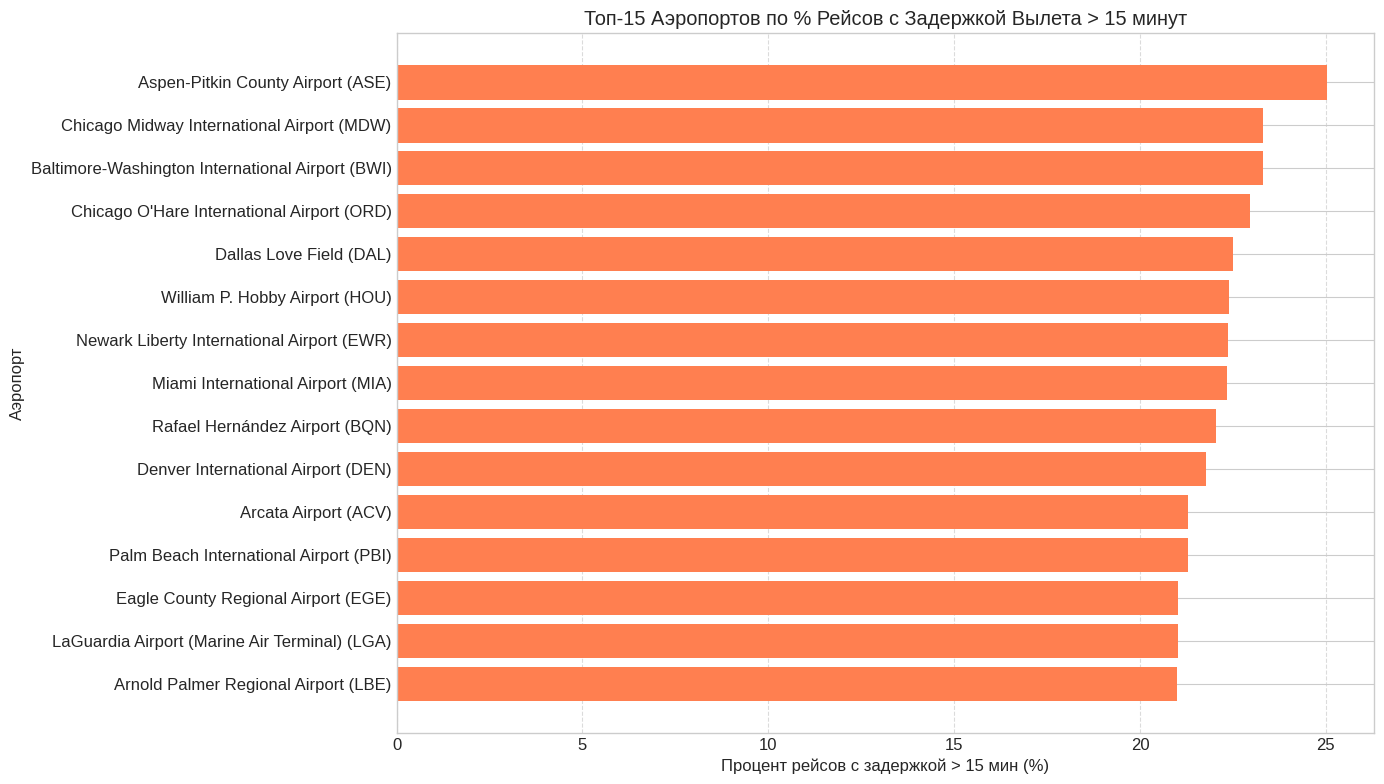

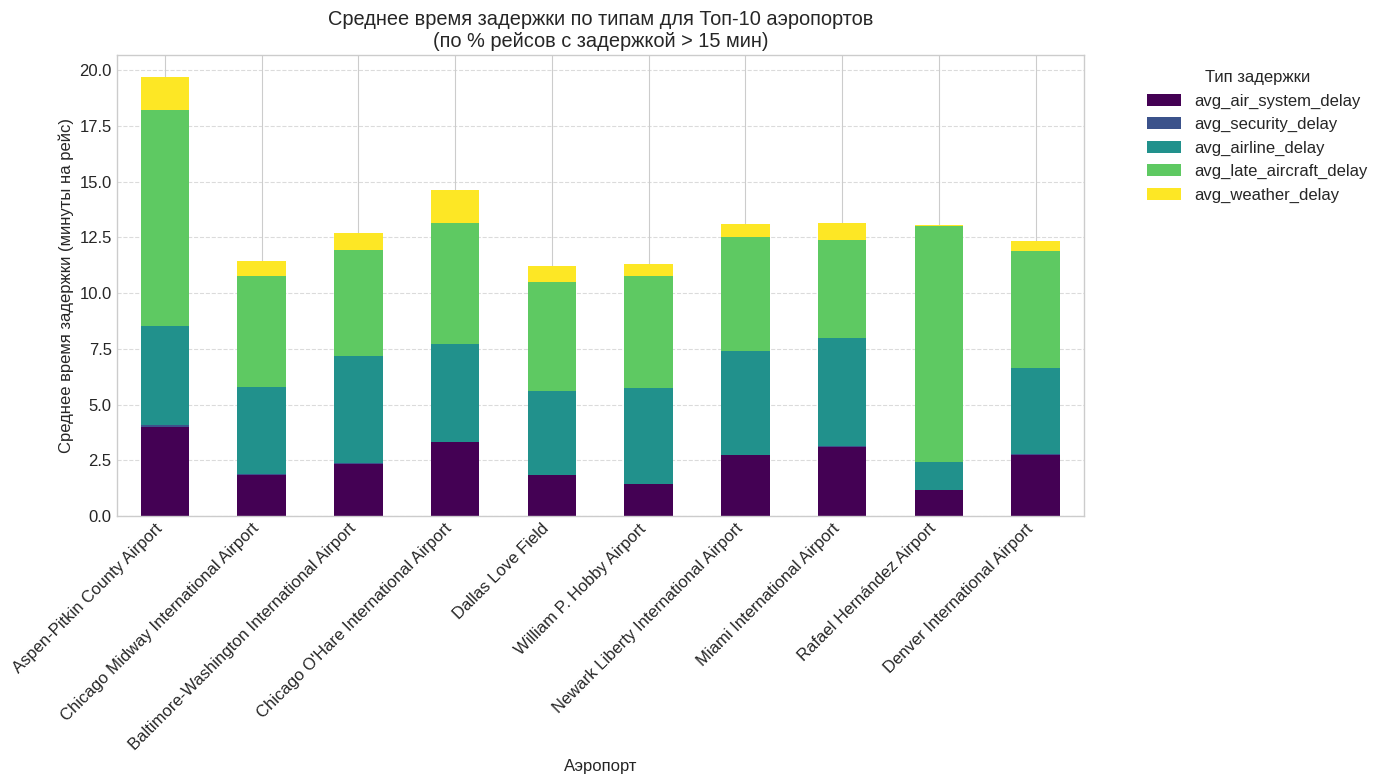

In [17]:
plt.figure(figsize=(16, 9))

sns.scatterplot(data=significant_airports, x='total_flights', y='avg_dep_delay', alpha=0.5, label='Другие аэропорты (>1000 рейсов)')

sns.scatterplot(data=worst_by_avg_delay, x='total_flights', y='avg_dep_delay', color='red', marker='X', s=120, label='Топ-15 по ср. задержке')

for i in range(len(worst_by_avg_delay)):
    row = worst_by_avg_delay.iloc[i]
    plt.annotate(row['ORIGIN_AIRPORT'],
                 (row['total_flights'], row['avg_dep_delay']),
                 textcoords="offset points",
                 xytext=(5, -5),
                 ha='left',
                 fontsize=9)

# Добавляем заголовки и метки осей ПОСЛЕ всех команд рисования для этой фигуры
plt.title('Средняя задержка вылета vs. Общее количество рейсов (Аэропорты > 1000 рейсов)')
plt.xlabel('Общее количество рейсов (лог. шкала)')
plt.ylabel('Средняя задержка вылета (минуты)')
plt.xscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()




# --- График 2: Топ-15 аэропортов по частоте значительных задержек ---
plt.figure(figsize=(14, 8))
# Берем топ 15 по проценту задержек
top_pct_delayed = worst_by_pct_delay.sort_values('pct_dep_delayed_15min', ascending=True) # Сортируем для горизонтального графика

plt.barh(top_pct_delayed['AIRPORT_NAME_ORIG'] + ' (' + top_pct_delayed['ORIGIN_AIRPORT'] + ')',
         top_pct_delayed['pct_dep_delayed_15min'],
         color='coral')

plt.title('Топ-15 Аэропортов по % Рейсов с Задержкой Вылета > 15 минут')
plt.xlabel('Процент рейсов с задержкой > 15 мин (%)')
plt.ylabel('Аэропорт')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# --- График 3: Разбивка типов задержек для топ-10 проблемных аэропортов ---
# Возьмем топ 10 из списка worst_by_pct_delay
top10_problem_airports = worst_by_pct_delay.head(10).set_index('AIRPORT_NAME_ORIG')


delay_avg_columns = ['avg_air_system_delay', 'avg_security_delay', 'avg_airline_delay',
                     'avg_late_aircraft_delay', 'avg_weather_delay']

# Строим stacked bar chart
ax = top10_problem_airports[delay_avg_columns].plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    colormap='viridis'
)

plt.title('Среднее время задержки по типам для Топ-10 аэропортов\n(по % рейсов с задержкой > 15 мин)')
plt.xlabel('Аэропорт')
plt.ylabel('Среднее время задержки (минуты на рейс)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип задержки', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [22]:
import folium
from folium.plugins import HeatMap
import warnings
from IPython.display import display # Убедимся, что display импортирован

try:
    if 'df_flights' not in locals() or 'df_airports' not in locals():
         raise NameError("Не найдены df_flights или df_airports. Запустите ячейки с загрузкой данных.")

    airport_traffic = df_flights.groupby('ORIGIN_AIRPORT').size().reset_index(name='total_flights')
    print(f"Рассчитан трафик для {len(airport_traffic)} аэропортов.")

    airport_locations = df_airports[['IATA_CODE', 'LATITUDE', 'LONGITUDE', 'AIRPORT', 'CITY', 'STATE']].copy()
    airport_map_data = pd.merge(
        airport_traffic,
        airport_locations,
        left_on='ORIGIN_AIRPORT',
        right_on='IATA_CODE',
        how='inner'
    )
    print(f"Найдено {len(airport_map_data)} аэропортов с трафиком и координатами.")

    initial_count = len(airport_map_data)
    airport_map_data.dropna(subset=['LATITUDE', 'LONGITUDE', 'total_flights'], inplace=True)
    airport_map_data = airport_map_data[airport_map_data['total_flights'] > 0]
    cleaned_count = len(airport_map_data)
    if initial_count != cleaned_count:
        print(f"Удалено {initial_count - cleaned_count} аэропортов без координат или с нулевым трафиком.")

    heat_data = airport_map_data[['LATITUDE', 'LONGITUDE', 'total_flights']].copy()
    heat_data['intensity'] = np.log1p(heat_data['total_flights'])
    heat_data_list = heat_data[['LATITUDE', 'LONGITUDE', 'intensity']].values.tolist()


    map_center = [39.8283, -98.5795]
    usa_heatmap = folium.Map(location=map_center, zoom_start=4)


    HeatMap(heat_data_list,
            name='Загруженность Аэропортов',
            radius=15,
            blur=12,
            max_zoom=5 # Оставляем max_zoom
           ).add_to(usa_heatmap)

    print("Тепловая карта создана. Отображение...")

    display(usa_heatmap)


except NameError as e:
     print(f"Ошибка: {e}. Убедись, что 'df_flights' и 'df_airports' загружены.")
except ImportError:
     print("Ошибка: Библиотека folium не найдена. Установите ее командой: !pip install folium")
except Exception as e:
     print(f"Произошла непредвиденная ошибка: {e}")

Рассчитан трафик для 322 аэропортов.
Найдено 322 аэропортов с трафиком и координатами.
Удалено 3 аэропортов без координат или с нулевым трафиком.
Тепловая карта создана. Отображение...


## Так как колаб не отображает карты я вставлю сюда скрин тепловой карты 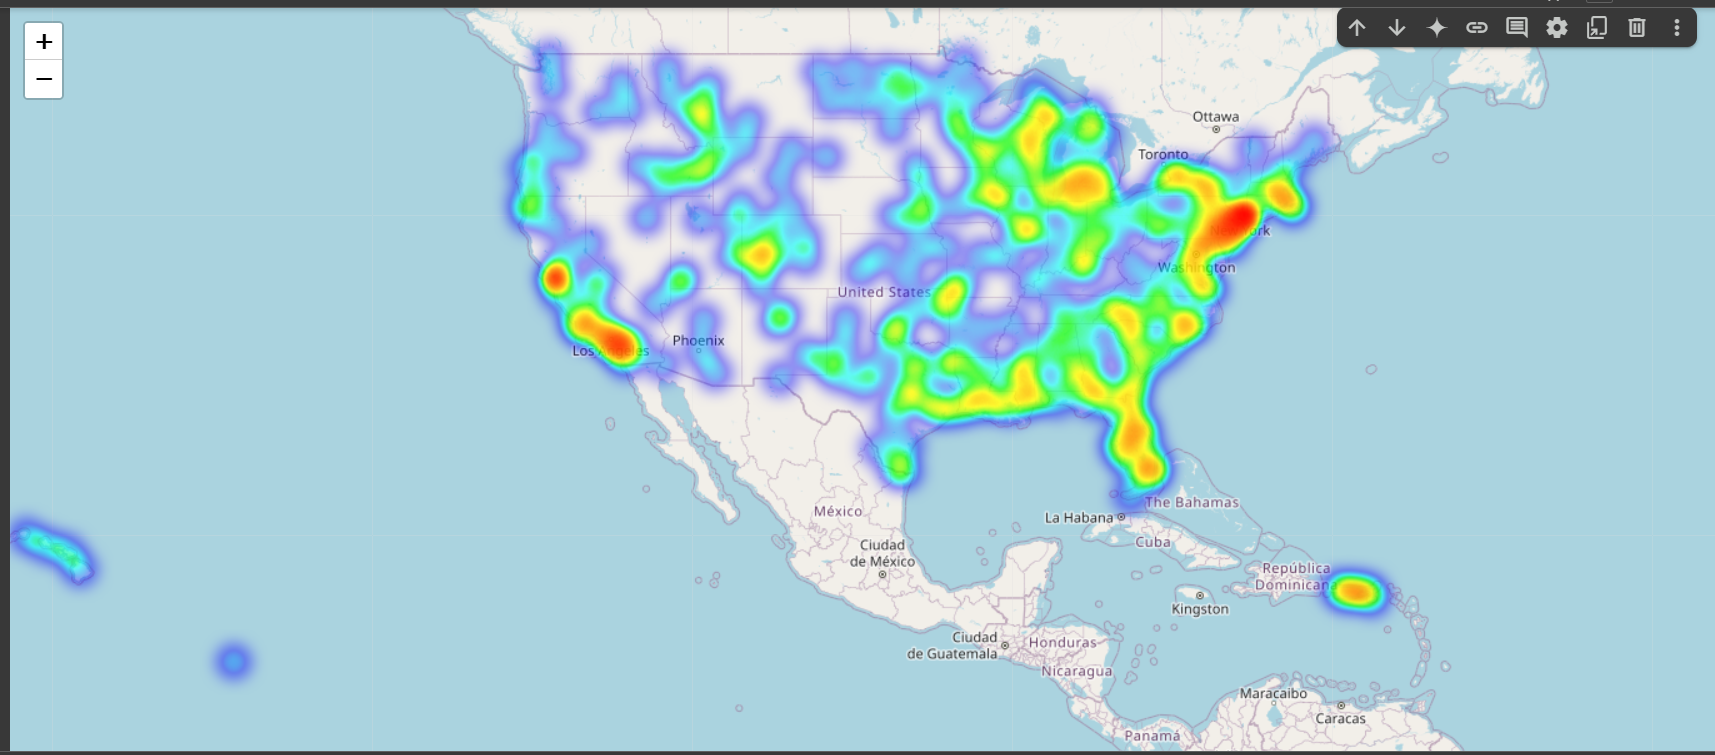

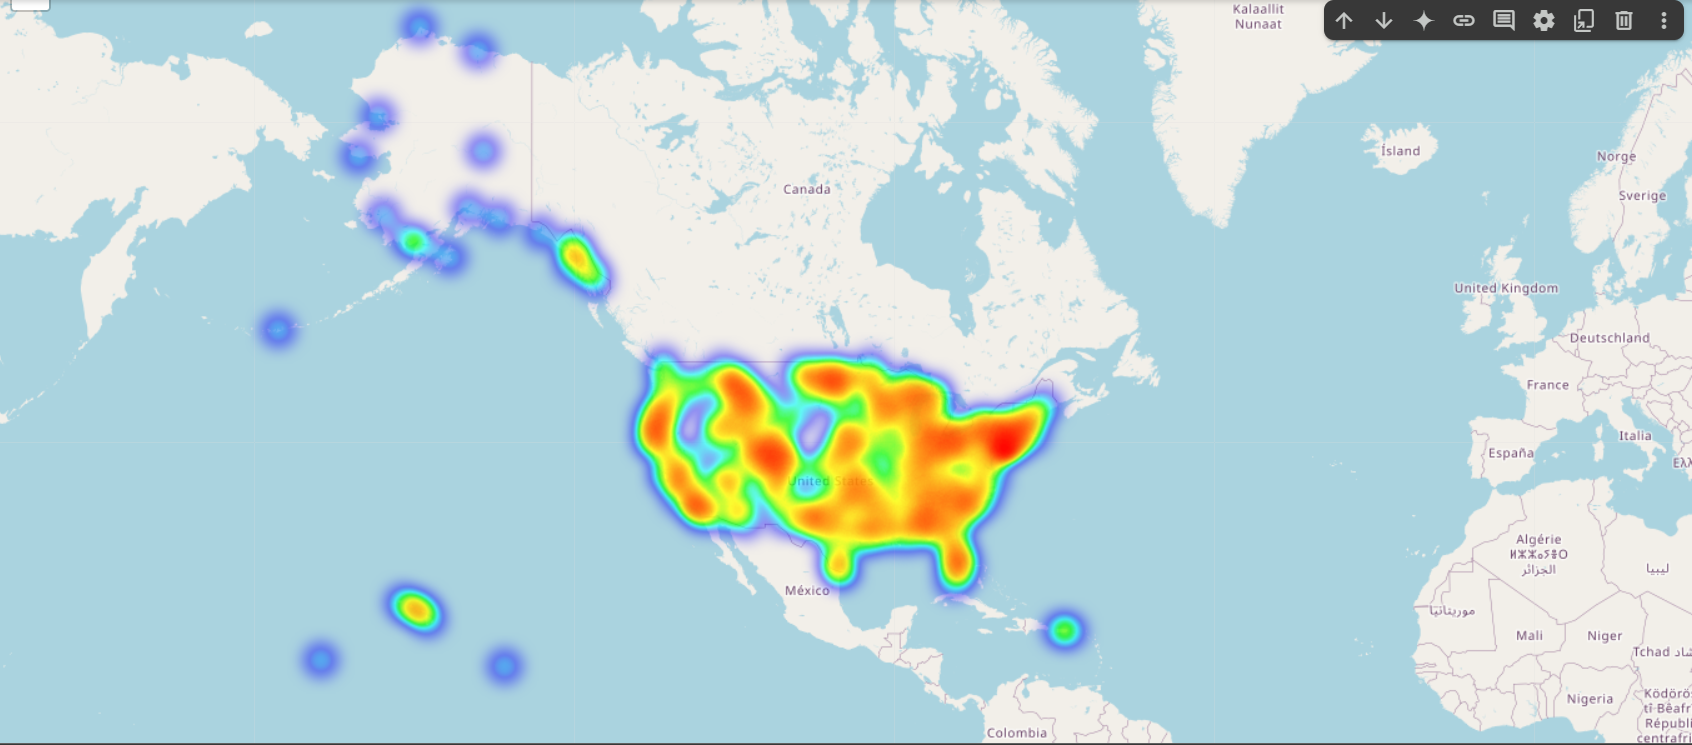

Выводы по анализу задержек в аэропортах
Проведенный анализ задержек в аэропортах отправления позволил выявить следующие характеристики и проблемные зоны:

Связь размера аэропорта и задержек: Диаграмма рассеяния (График 1) показывает, что хотя прямой строгой зависимости между общим числом рейсов и средней задержкой вылета нет, многие крупные хабы (например, Чикаго О'Хэр - ORD, Ньюарк - EWR, Балтимор - BWI, Ла-Гуардия - LGA, Майами - MIA), отмеченные красными крестиками, испытывают как значительный трафик, так и высокие средние задержки вылета (более 12-14 минут). В то же время, некоторые аэропорты с относительно небольшим трафиком (например, Аспен - ASE, Игл - EGE) демонстрируют самые высокие средние задержки, что указывает на возможные специфические проблемы (погодные условия, инфраструктурные ограничения).

Частота значительных задержек: Анализ процента рейсов с задержкой вылета более 15 минут (График 2) выявил критическую ситуацию в ряде крупных и средних аэропортов. Лидерами по этой метрике являются Чикаго Мидуэй (MDW), Балтимор (BWI), Чикаго О'Хэр (ORD), Даллас Лав Филд (DAL), Хьюстон Хобби (HOU), Ньюарк (EWR) и Майами (MIA). В этих аэропортах примерно каждый четвертый-пятый рейс (22-25%) вылетает со значительной задержкой. Это указывает на системные проблемы с пунктуальностью, затрагивающие большое число пассажиров. Аэропорт Аспен (ASE) также выделяется очень высоким процентом задержек.

Основные причины задержек в проблемных аэропортах: Анализ структуры задержек для топ-10 аэропортов с наиболее частыми задержками (График 3) показывает, что основной вклад в среднее время задержки вносят:

LATE_AIRCRAFT_DELAY (Задержка из-за позднего прибытия воздушного судна): Этот тип задержки часто доминирует или является одним из основных в крупных хабах (например, ORD, EWR, DEN, MDW). Это свидетельствует о "эффекте домино", когда задержки накапливаются и распространяются по сети маршрутов. Проблема может быть связана с недостаточной эффективностью оборота судов, расписанием или сетевыми сбоями.
AIRLINE_DELAY (Задержка по вине авиакомпании): Также является значительным фактором во многих из этих аэропортов. Это указывает на проблемы в операционной деятельности самих авиакомпаний (управление экипажами, техническое обслуживание, наземные службы).
AIR_SYSTEM_DELAY (Задержка авиационной системы): Этот тип задержки также заметен в крупных загруженных аэропортах, что может указывать на недостаточную пропускную способность воздушного пространства или самого аэропорта, проблемы с управлением воздушным движением (УВД).

Рекомендации для Министерства Транспорта:

Обратить пристальное внимание на крупные хабы (ORD, MDW, BWI, EWR, DAL, HOU, MIA, DEN, LGA), где частота значительных задержек наиболее высока. Необходимо проанализировать причины доминирующих типов задержек (позднее прибытие ВС, вина АК, система УВД) и разработать меры по повышению эффективности оборота судов, оптимизации расписаний и увеличению пропускной способности.
Провести отдельное расследование причин высоких средних задержек в небольших, но проблемных аэропортах (ASE, EGE), учитывая их специфику (сезонность, погода, инфраструктура).

In [16]:
print("Начало расчета метрик по авиакомпаниям...")

airline_stats = df_flights.groupby('AIRLINE').agg(
    total_flights=('FLIGHT_NUMBER', 'count'),      # Общее количество рейсов
    total_cancelled=('CANCELLED', 'sum'),          # Общее количество отмен
    avg_dep_delay=('DEPARTURE_DELAY', 'mean'),     # Средняя задержка вылета
    median_dep_delay=('DEPARTURE_DELAY', 'median'),# Медианная задержка вылета
    avg_arr_delay=('ARRIVAL_DELAY', 'mean'),       # Средняя задержка прилета
    median_arr_delay=('ARRIVAL_DELAY', 'median')   # Медианная задержка прилета
).reset_index()

airline_stats['cancellation_rate'] = (airline_stats['total_cancelled'] / airline_stats['total_flights']) * 100

def calculate_delayed_pct(group):
    dep_delayed_15min = (group['DEPARTURE_DELAY'] > 15).mean() * 100
    arr_delayed_15min = (group['ARRIVAL_DELAY'] > 15).mean() * 100
    return pd.Series({
        'pct_dep_delayed_15min': dep_delayed_15min,
        'pct_arr_delayed_15min': arr_delayed_15min
    })

delayed_pct_stats = df_flights.groupby('AIRLINE').apply(calculate_delayed_pct).reset_index()

airline_stats = pd.merge(airline_stats, delayed_pct_stats, on='AIRLINE', how='left')

print(f"Рассчитаны метрики для {len(airline_stats)} авиакомпаний.")

min_airline_flights_threshold = 1000 # Можно изменить
significant_airlines = airline_stats[airline_stats['total_flights'] >= min_airline_flights_threshold].copy()
print(f"Оставлено {len(significant_airlines)} авиакомпаний с >= {min_airline_flights_threshold} рейсами для анализа.")

worst_by_cancel_rate = significant_airlines.nlargest(10, 'cancellation_rate')
worst_by_dep_delay_pct = significant_airlines.nlargest(10, 'pct_dep_delayed_15min')
worst_by_avg_dep_delay = significant_airlines.nlargest(10, 'avg_dep_delay')

print("\n--- Топ-10 авиакомпаний по ДОЛЕ отмененных рейсов (%) ---")
print(worst_by_cancel_rate[['AIRLINE', 'total_flights', 'cancellation_rate', 'pct_dep_delayed_15min']])

print("\n--- Топ-10 авиакомпаний по ПРОЦЕНТУ рейсов с задержкой вылета > 15 мин (%) ---")
print(worst_by_dep_delay_pct[['AIRLINE', 'total_flights', 'cancellation_rate', 'pct_dep_delayed_15min', 'avg_dep_delay']])

print("\n--- Топ-10 авиакомпаний по СРЕДНЕЙ задержке вылета (минуты) ---")
print(worst_by_avg_dep_delay[['AIRLINE', 'total_flights', 'avg_dep_delay', 'pct_dep_delayed_15min']])


# Дополнительно: Посмотрим на CANCELLATION_REASON, если есть данные
if 'CANCELLATION_REASON' in df_flights.columns:
    print("\n--- Распределение причин отмен (если есть данные) ---")
    # Убираем NaN и считаем причины
    cancel_reasons = df_flights.dropna(subset=['CANCELLATION_REASON'])['CANCELLATION_REASON'].value_counts()
    if not cancel_reasons.empty:
        print(cancel_reasons)
    else:
        print("Недостаточно данных о причинах отмен для анализа.")
else:
    print("\nКолонка CANCELLATION_REASON отсутствует.")


print("\nРасчеты и идентификация проблемных авиакомпаний завершены.")

Начало расчета метрик по авиакомпаниям...


<ipython-input-16-a5beece06604>:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  delayed_pct_stats = df_flights.groupby('AIRLINE').apply(calculate_delayed_pct).reset_index()


Рассчитаны метрики для 14 авиакомпаний.
Оставлено 14 авиакомпаний с >= 1000 рейсами для анализа.

--- Топ-10 авиакомпаний по ДОЛЕ отмененных рейсов (%) ---
   AIRLINE  total_flights  cancellation_rate  pct_dep_delayed_15min
7       MQ         272650           5.410600              19.193471
4       EV         526249           2.803616              16.798322
11      US         198715           2.046650              14.117203
8       NK         107171           1.812990              26.907466
9       OO         539545           1.801333              16.345995
2       B6         245135           1.691313              21.192404
0       AA         648694           1.571465              17.013106
10      UA         469829           1.371776              23.388722
13      WN        1157339           1.358375              20.778095
12      VX          56439           0.905402              17.363880

--- Топ-10 авиакомпаний по ПРОЦЕНТУ рейсов с задержкой вылета > 15 мин (%) ---
   AIRLINE  tota

Расчет метрик по авиакомпаниям...

Создание графиков для анализа авиакомпаний...


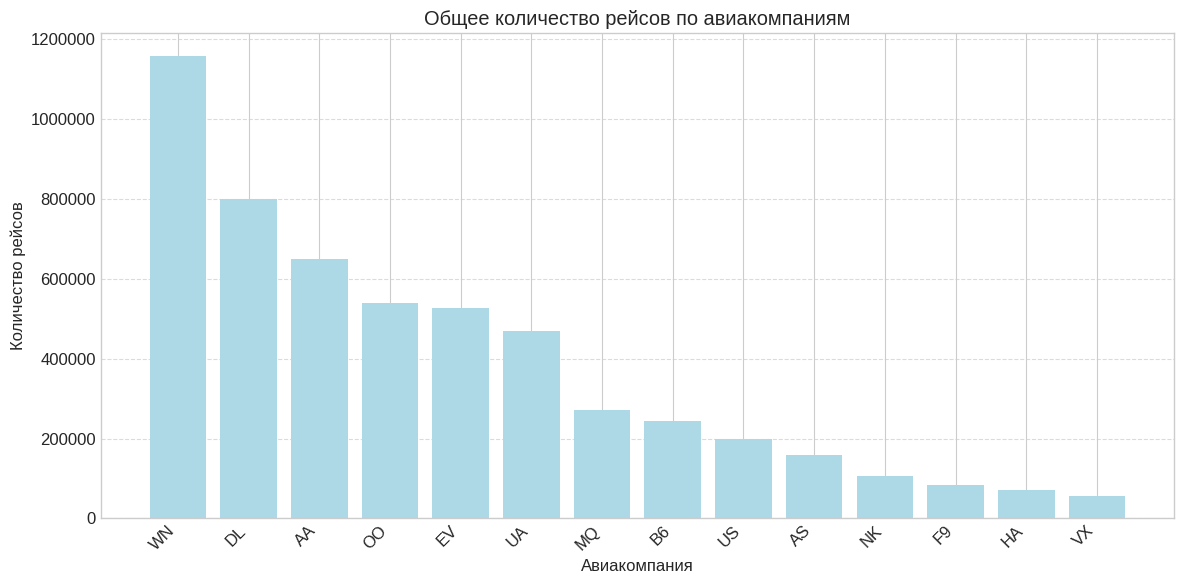

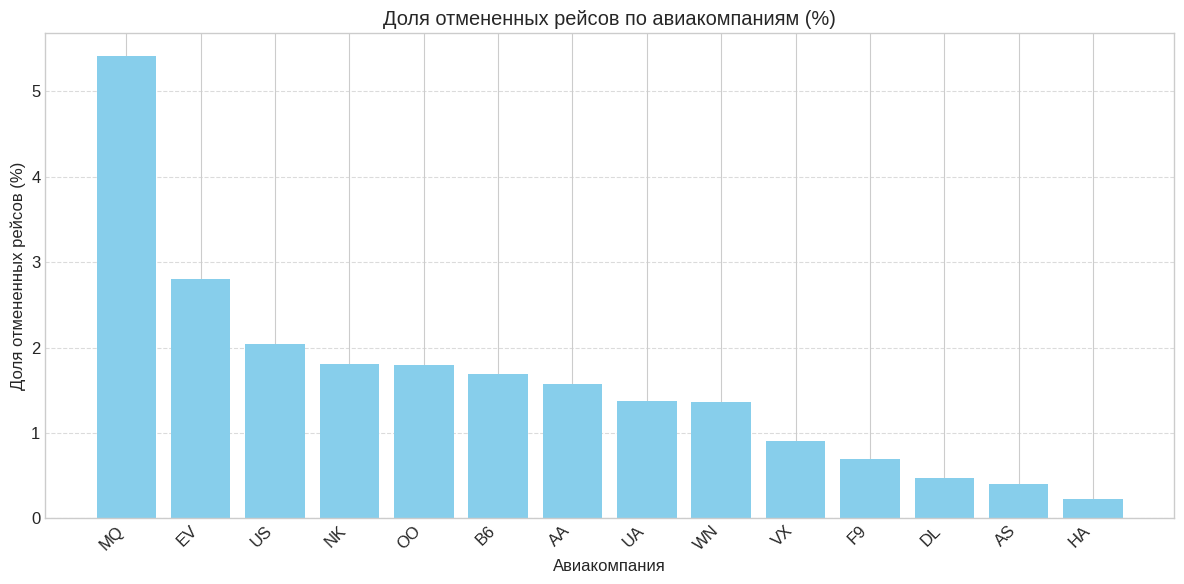

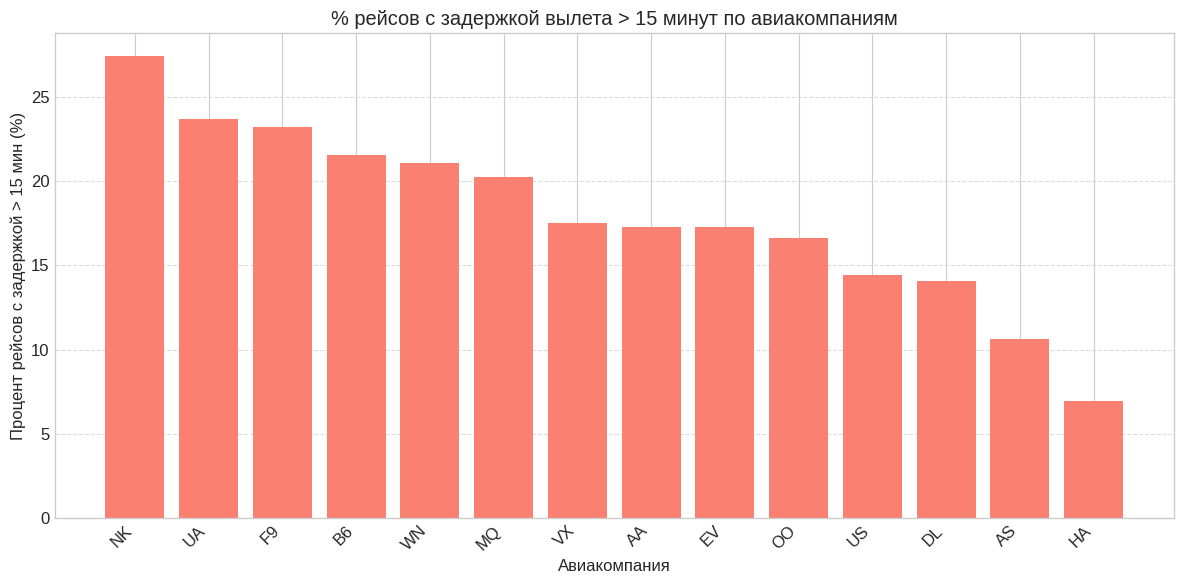

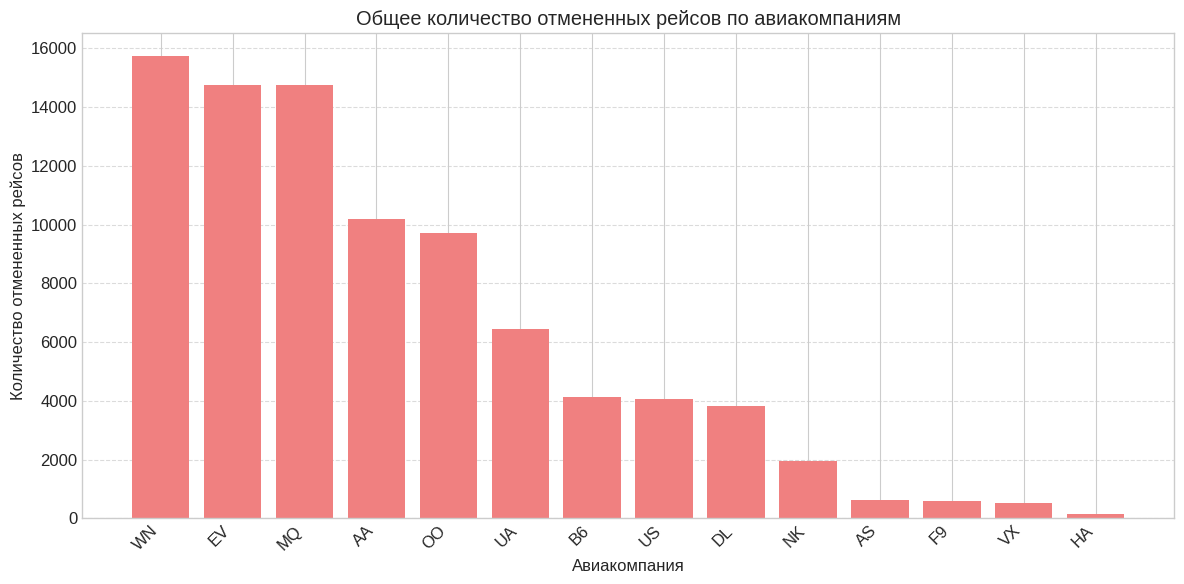


Графики по авиакомпаниям созданы.


In [24]:
import seaborn as sns

print("Расчет метрик по авиакомпаниям...")

try:
    if 'df_flights' not in locals() and 'df_flights' not in globals():
        raise NameError("'df_flights' не найден. Убедись, что данные загружены и обработаны.")
    airline_stats_base = df_flights.groupby('AIRLINE').agg(
        total_flights=('FLIGHT_NUMBER', 'count'),      # Общее количество рейсов
        total_cancelled=('CANCELLED', 'sum'),          # Общее количество отмен
        avg_dep_delay=('DEPARTURE_DELAY', 'mean'),     # Средняя задержка вылета
        median_dep_delay=('DEPARTURE_DELAY', 'median'),# Медианная задержка вылета
        avg_arr_delay=('ARRIVAL_DELAY', 'mean'),       # Средняя задержка прилета
        median_arr_delay=('ARRIVAL_DELAY', 'median')   # Медианная задержка прилета
    ).reset_index()

    airline_stats_base['cancellation_rate'] = (airline_stats_base['total_cancelled'] / airline_stats_base['total_flights']) * 100

    def calculate_delayed_pct(group):
        dep_delayed_15min = (group['DEPARTURE_DELAY'].dropna() > 15).mean() * 100
        arr_delayed_15min = (group['ARRIVAL_DELAY'].dropna() > 15).mean() * 100
        return pd.Series({
            'pct_dep_delayed_15min': dep_delayed_15min,
            'pct_arr_delayed_15min': arr_delayed_15min
        })

    with warnings.catch_warnings():
         warnings.simplefilter("ignore", category=DeprecationWarning)
         delayed_pct_stats = df_flights.groupby('AIRLINE').apply(calculate_delayed_pct).reset_index()

    airline_stats = pd.merge(airline_stats_base, delayed_pct_stats, on='AIRLINE', how='left')


    if not airline_stats.empty:
        print("\nСоздание графиков для анализа авиакомпаний...")

        airline_stats_sorted_flights = airline_stats.sort_values('total_flights', ascending=False)
        airline_stats_sorted_cancel_rate = airline_stats.sort_values('cancellation_rate', ascending=False)
        airline_stats_sorted_dep_delay_pct = airline_stats.sort_values('pct_dep_delayed_15min', ascending=False)
        airline_stats_sorted_total_cancel = airline_stats.sort_values('total_cancelled', ascending=False)

        plt.figure(figsize=(12, 6))
        plt.bar(airline_stats_sorted_flights['AIRLINE'], airline_stats_sorted_flights['total_flights'], color='lightblue')
        plt.title('Общее количество рейсов по авиакомпаниям')
        plt.xlabel('Авиакомпания')
        plt.ylabel('Количество рейсов')
        plt.xticks(rotation=45, ha="right")
        plt.ticklabel_format(style='plain', axis='y')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(12, 6))
        plt.bar(airline_stats_sorted_cancel_rate['AIRLINE'], airline_stats_sorted_cancel_rate['cancellation_rate'], color='skyblue')
        plt.title('Доля отмененных рейсов по авиакомпаниям (%)')
        plt.xlabel('Авиакомпания')
        plt.ylabel('Доля отмененных рейсов (%)')
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(12, 6))
        plt.bar(airline_stats_sorted_dep_delay_pct['AIRLINE'], airline_stats_sorted_dep_delay_pct['pct_dep_delayed_15min'], color='salmon')
        plt.title('% рейсов с задержкой вылета > 15 минут по авиакомпаниям')
        plt.xlabel('Авиакомпания')
        plt.ylabel('Процент рейсов с задержкой > 15 мин (%)')
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(12, 6))
        plt.bar(airline_stats_sorted_total_cancel['AIRLINE'], airline_stats_sorted_total_cancel['total_cancelled'], color='lightcoral')
        plt.title('Общее количество отмененных рейсов по авиакомпаниям')
        plt.xlabel('Авиакомпания')
        plt.ylabel('Количество отмененных рейсов')
        plt.xticks(rotation=45, ha="right")
        plt.ticklabel_format(style='plain', axis='y')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print("\nГрафики по авиакомпаниям созданы.")
    else:
        print("Не удалось создать графики, так как данные авиакомпаний не были рассчитаны или пусты.")

except NameError as e:
     print(f"Ошибка: {e}. Убедись, что переменная 'df_flights' существует и содержит нужные колонки.")
except Exception as e:
     print(f"Произошла непредвиденная ошибка при расчете или построении графиков: {e}")

### Выводы по анализу эффективности авиакомпаний

Анализ данных по авиакомпаниям с использованием как абсолютных показателей, так и относительных (долей и процентов) позволил выявить следующие тенденции и проблемные авиаперевозчики:

1.  **Важность относительных показателей:** Сравнение рейтингов показало, что крупнейшие авиакомпании по числу рейсов (WN, DL, AA) не всегда являются худшими по относительным показателям. Например, лидеры по **доле (%) отмененных рейсов** – MQ (Envoy Air, ~5.4%), EV (ExpressJet, ~2.8%) и US (US Airways, ~2.0%) – не входят в топ-3 по общему числу рейсов. Это подчеркивает, что некоторые региональные или находящиеся в особых условиях (как US Airways в процессе слияния с AA в 2015 году) авиакомпании сталкиваются с **непропорционально высокими проблемами с отменами** по сравнению с их масштабом операций. В то же время, авиакомпании с наибольшим *абсолютным числом* отмен (WN, AA) имеют более низкую *долю* отмен благодаря своему огромному объему перевозок.

2.  **Проблемы с отменами:** Авиакомпании **MQ (Envoy Air)** и **EV (ExpressJet)** выделяются как наиболее проблемные с точки зрения *доли* отмененных рейсов (5.4% и 2.8% соответственно). Учитывая, что они часто выполняют региональные рейсы для крупных перевозчиков, их низкая надежность может оказывать существенное влияние на связанность маршрутной сети и удовлетворенность пассажиров на региональных направлениях.

3.  **Проблемы с пунктуальностью (задержками):** Лидерами по **частоте значительных задержек вылета** (более 15 минут) являются **NK (Spirit Airlines, ~27.4%), UA (United Airlines, ~23.7%) и F9 (Frontier Airlines, ~23.2%)**. Примечательно, что это сочетание ультра-лоукост перевозчиков (NK, F9) и одного из крупнейших традиционных перевозчиков (UA). Это может указывать на разные причины: у лоукостеров – возможно, на агрессивное расписание и минимальное время оборота судов, у UA – возможно, на проблемы в крупных хабах или сложности в управлении большой и сложной сетью. Важно, что **лидеры по частоте задержек не совпадают с лидерами по доле отмен**, указывая на разные операционные проблемы у разных типов авиакомпаний.

4.  **Распределение причин отмен:** Хотя детальный анализ причин отмен затруднен из-за большого количества пропусков в данных, общая статистика показывает, что основные причины отмен кодируются как 'B' (Погода - Weather) и 'A' (Перевозчик - Carrier), за которыми следует 'C' (Система УВД - National Air System).

**Рекомендации для Министерства Транспорта:**
* Провести **целевую проверку операционной деятельности авиакомпаний MQ и EV**, чтобы выявить причины высокой доли отмен на региональных рейсах.
* Проанализировать **факторы, приводящие к высокой частоте задержек** у авиакомпаний **NK, UA и F9**




--- Сводная статистика по типам задержек ---
               Total Minutes  Frequency (Count)  \
Air System        13533065.0             532628   
Security             77945.0               3340   
Airline           18966945.0             538573   
Late Aircraft     23767674.0             529110   
Weather            2991008.0              62610   

               Average Minutes (when occurred > 0)  
Air System                               25.408099  
Security                                 23.336826  
Airline                                  35.217037  
Late Aircraft                            44.920100  
Weather                                  47.772049  


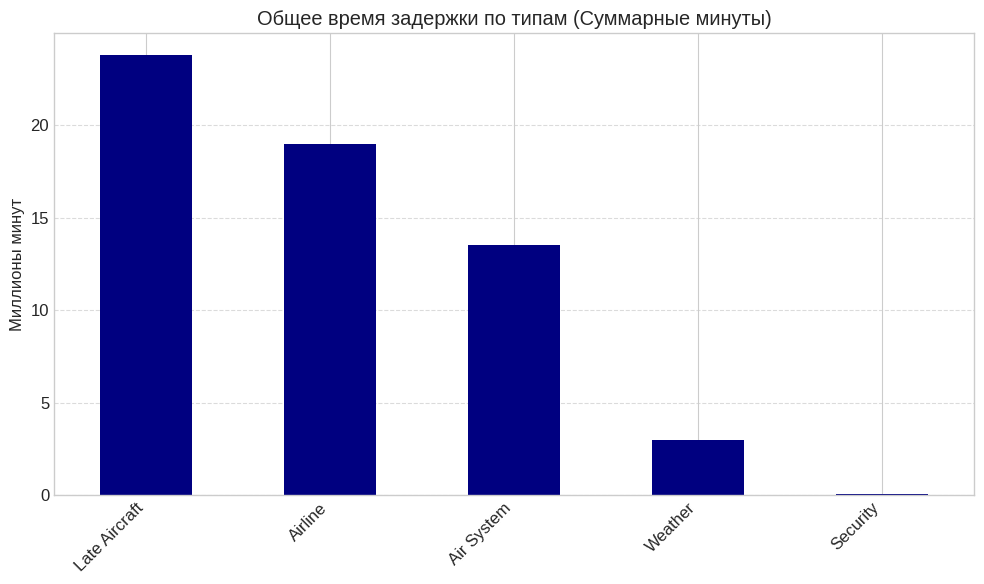

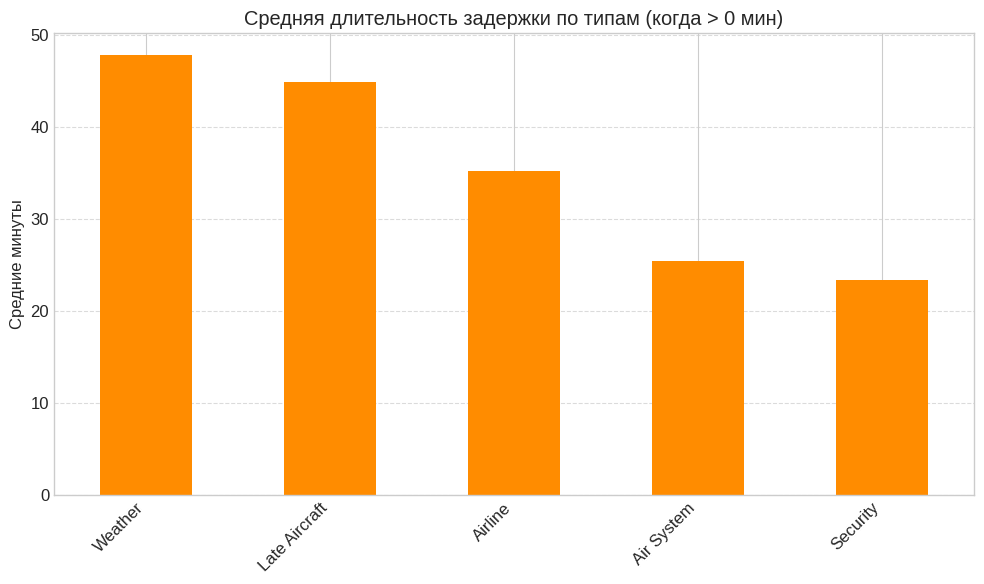

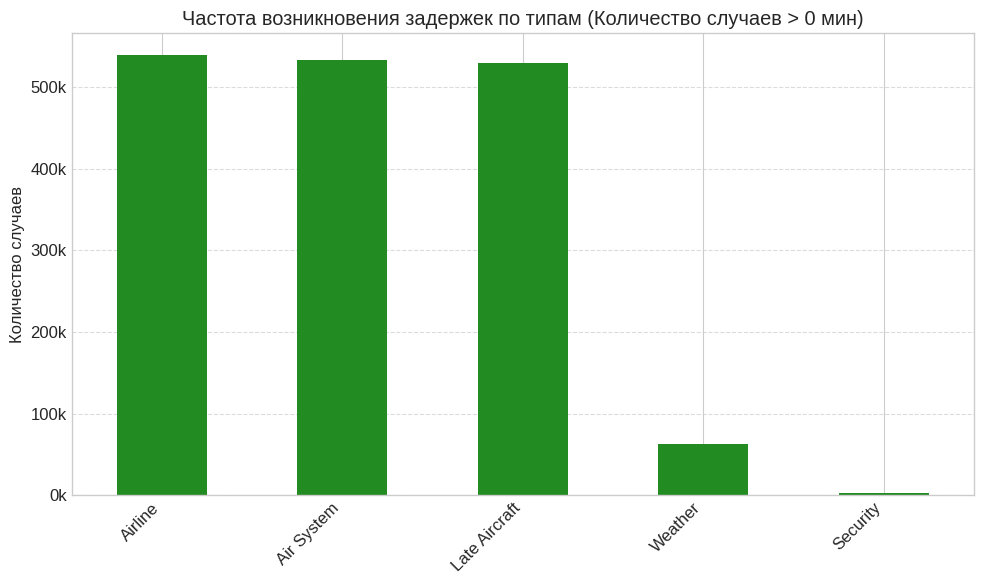

In [25]:
delay_type_columns = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

df_delays = df_flights[delay_type_columns].fillna(0)

total_delay_minutes = df_delays.sum()

delay_frequency = (df_delays > 0).sum()

mean_delay_when_occurred = {}
for col in delay_type_columns:
    valid_delays = df_flights.loc[df_flights[col] > 0, col].dropna()
    if not valid_delays.empty:
        mean_delay_when_occurred[col] = valid_delays.mean()
    else:
        mean_delay_when_occurred[col] = 0
mean_delay_when_occurred = pd.Series(mean_delay_when_occurred)

delay_stats_summary = pd.DataFrame({
    'Total Minutes': total_delay_minutes,
    'Frequency (Count)': delay_frequency,
    'Average Minutes (when occurred > 0)': mean_delay_when_occurred
})

delay_stats_summary.index = ['Air System', 'Security', 'Airline', 'Late Aircraft', 'Weather']

print("\n--- Сводная статистика по типам задержек ---")
print(delay_stats_summary)

plt.figure(figsize=(10, 6))
delay_stats_summary['Total Minutes'].sort_values(ascending=False).plot(kind='bar', color='navy')
plt.title('Общее время задержки по типам (Суммарные минуты)')
plt.ylabel('Миллионы минут')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x / 1_000_000), ',')))
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
delay_stats_summary['Average Minutes (when occurred > 0)'].sort_values(ascending=False).plot(kind='bar', color='darkorange')
plt.title('Средняя длительность задержки по типам (когда > 0 мин)')
plt.ylabel('Средние минуты')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
delay_stats_summary['Frequency (Count)'].sort_values(ascending=False).plot(kind='bar', color='forestgreen')
plt.title('Частота возникновения задержек по типам (Количество случаев > 0 мин)')
plt.ylabel('Количество случаев')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x / 1_000), ',') + 'k' if x < 1_000_000 else format(int(x / 1_000_000), ',') + 'M'))
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Так как в данных нет октября, то буду строить без него


--- Месячная статистика ---
   MONTH  total_AIR_SYSTEM_DELAY  total_SECURITY_DELAY  total_AIRLINE_DELAY  \
0      1               1278055.0                6700.0            1708155.0   
1      2               1349173.0                4580.0            1712660.0   
2      3               1228893.0                6586.0            1818680.0   
3      4               1118027.0                3660.0            1490594.0   
4      5               1254652.0                5711.0            1667920.0   

   total_LATE_AIRCRAFT_DELAY  total_WEATHER_DELAY  total_flights  \
0                  2183865.0             263087.0         469968   
1                  2157918.0             411265.0         429191   
2                  2156090.0             228661.0         504312   
3                  1785437.0             221590.0         485151   
4                  2172521.0             336555.0         496993   

   avg_dep_delay  avg_arr_delay  
0       9.759471       5.813583  
1      11.885284   

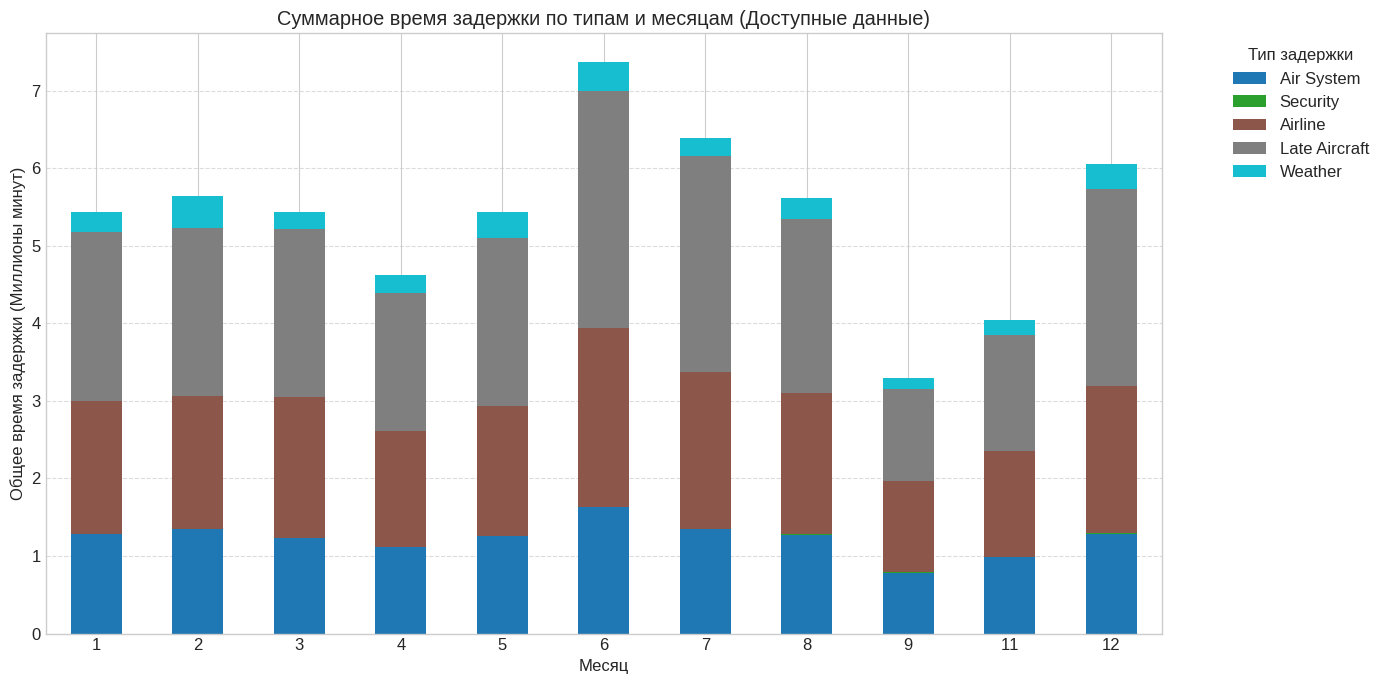

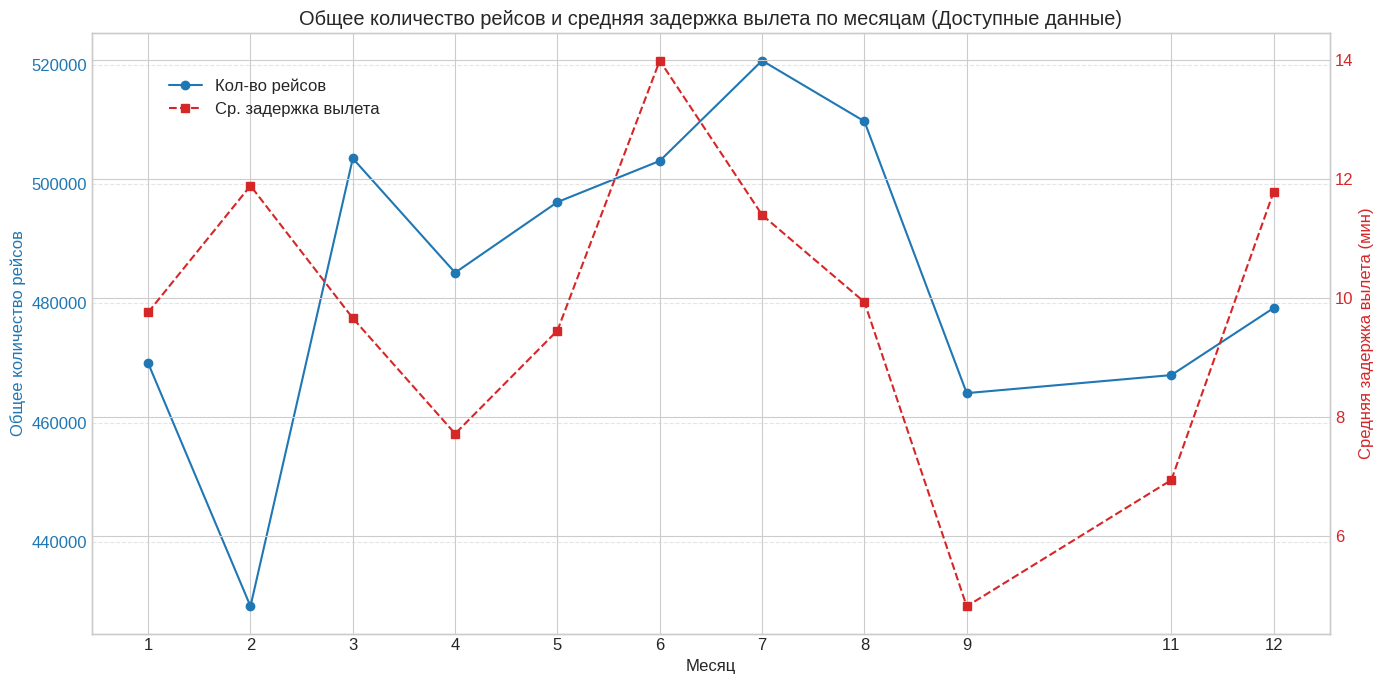


Расчеты и графики по месячным тенденциям завершены.


In [26]:
try:
    if 'df_flights' not in locals() or 'df_flights' not in globals():
        raise NameError("'df_flights' не найден. Убедись, что данные загружены и обработаны.")

    delay_type_columns = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

    df_flights_delay_filled = df_flights.copy()
    df_flights_delay_filled[delay_type_columns] = df_flights_delay_filled[delay_type_columns].fillna(0)

    monthly_stats_calc = df_flights_delay_filled.groupby('MONTH').agg(
        **{f'total_{col}': (col, 'sum') for col in delay_type_columns},
        total_flights=('FLIGHT_NUMBER', 'count')
    )
    avg_monthly_delays_calc = df_flights.groupby('MONTH').agg(
        avg_dep_delay = ('DEPARTURE_DELAY', 'mean'),
        avg_arr_delay = ('ARRIVAL_DELAY', 'mean')
    ).reset_index()

    monthly_stats = monthly_stats_calc.reset_index()
    monthly_stats = pd.merge(monthly_stats, avg_monthly_delays_calc, on='MONTH', how='left')

    monthly_stats = monthly_stats.sort_values('MONTH').reset_index(drop=True)

    print("\n--- Месячная статистика ---")
    print(monthly_stats.head())
    print(f"\nКоличество месяцев в статистике: {len(monthly_stats)}")
    if len(monthly_stats) < 12:
        all_months_set = set(range(1, 13))
        present_months_set = set(monthly_stats['MONTH'].unique())
        missing = sorted(list(all_months_set - present_months_set))
        print(f"ВНИМАНИЕ: Отсутствуют данные за месяц(ы): {missing}")
    else:
        print("Данные за все 12 месяцев присутствуют.")

    if not monthly_stats.empty:
        print("\nСоздание графиков месячных тенденций (с коррекцией оси X)...")

        # --- График 4: Суммарные задержки по типам и месяцам (Stacked Bar) ---
        plt.figure(figsize=(14, 7))
        plot_columns = [f'total_{col}' for col in delay_type_columns]
        plot_labels = ['Air System', 'Security', 'Airline', 'Late Aircraft', 'Weather']

        # Получаем РЕАЛЬНЫЕ номера месяцев, которые есть в данных
        present_months = monthly_stats['MONTH'].tolist()
        # Создаем индексы для позиционирования столбцов (0, 1, 2, ...)
        x_ticks_indices = np.arange(len(present_months))

        # Строим столбчатую диаграмму
        monthly_stats[plot_columns].plot(
            kind='bar',
            stacked=True,
            ax=plt.gca(),
            colormap='tab10',
            figsize=(14, 7),
            # Не используем напрямую month как X, чтобы избежать пропусков на оси
        )

        plt.title('Суммарное время задержки по типам и месяцам (Доступные данные)')
        plt.xlabel('Месяц')
        plt.ylabel('Общее время задержки (Миллионы минут)')
        # --- ИСПРАВЛЕНО: Ставим метки на позициях 0, 1, 2... и подписываем их реальными номерами месяцев ---
        plt.xticks(ticks=x_ticks_indices, labels=[str(m) for m in present_months], rotation=0)
        plt.legend(plot_labels, title='Тип задержки', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x / 1_000_000), ',')))
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()


        # --- График 5: Количество рейсов vs Средняя задержка вылета (Dual Axis Line) ---
        fig, ax1 = plt.subplots(figsize=(14, 7))

        color1 = 'tab:blue'
        ax1.set_xlabel('Месяц')
        ax1.set_ylabel('Общее количество рейсов', color=color1)
        # --- ИСПРАВЛЕНО: Используем реальные номера месяцев для оси X графика ---
        ax1.plot(monthly_stats['MONTH'], monthly_stats['total_flights'], color=color1, marker='o', label='Кол-во рейсов')
        ax1.tick_params(axis='y', labelcolor=color1)
        ax1.ticklabel_format(style='plain', axis='y')
        # --- ИСПРАВЛЕНО: Устанавливаем метки оси X только для присутствующих месяцев ---
        ax1.set_xticks(present_months)
        ax1.grid(True, axis='y', linestyle='--', alpha=0.5) # Сетка только для левой оси для наглядности

        ax2 = ax1.twinx()
        color2 = 'tab:red'
        ax2.set_ylabel('Средняя задержка вылета (мин)', color=color2)
        # --- ИСПРАВЛЕНО: Используем реальные номера месяцев для оси X графика ---
        ax2.plot(monthly_stats['MONTH'], monthly_stats['avg_dep_delay'], color=color2, marker='s', linestyle='--', label='Ср. задержка вылета')
        ax2.tick_params(axis='y', labelcolor=color2)

        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(0.05, 0.95))

        plt.title('Общее количество рейсов и средняя задержка вылета по месяцам (Доступные данные)')
        fig.tight_layout()
        plt.show()

        print("\nРасчеты и графики по месячным тенденциям завершены.")
    else:
        print("DataFrame 'monthly_stats' пуст, графики не построены.")

except NameError as e:
     print(f"Ошибка: {e}. Убедись, что 'df_flights' существует.")
except Exception as e:
     print(f"Произошла ошибка: {e}")

### Выводы по анализу типов задержек и их сезонности

Анализ различных типов задержек и их распределения по месяцам (за исключением отсутствующего Октября) позволил сделать следующие выводы:

1.  **Основные виновники задержек:** В целом по году, наибольший вклад в **суммарное потерянное время** вносят задержки из-за **опоздания предыдущего рейса (`Late Aircraft`)**, по **вине авиакомпании (`Airline`)** и из-за проблем в **авиационной системе (`Air System`)**. Задержки по вине **погоды (`Weather`)** и **служб безопасности (`Security`)** в сумме дают гораздо меньший вклад. При этом, когда задержки по **погоде** или из-за **опоздания самолета** все же случаются, они являются **наиболее длительными** в среднем. Задержки типа `Air System`, `Airline` и `Late Aircraft` происходят **наиболее часто**.

2.  **Сезонность общей задержки:** Максимальные **суммарные** задержки наблюдаются в **Июне, Июле и Декабре**. Это указывает на пиковые периоды: начало летнего сезона отпусков и зимние праздники, когда нагрузка на систему и неблагоприятные погодные условия приводят к наибольшему общему времени потерь.

3.  **Сезонные изменения в структуре задержек:**
    * Доля задержек, связанных с **погодой (`Weather`)**, ожидаемо максимальна зимой, достигая пика (среди имеющихся данных) в **Феврале** (7.3% от всех задержек в этом месяце).
    * Доля задержек из-за **опоздания предыдущего рейса (`Late Aircraft`)** максимальна в **Июле** (43.6%). Это подтверждает гипотезу о "эффекте домино", который усиливается в месяц абсолютного пика перевозок, когда система работает на пределе возможностей.
    * Доля задержек по **вине авиакомпании (`Airline`)** достигает максимума в **Сентябре** (35.8%).
    * Доля задержек **авиасистемы (`Air System`)** максимальна в **Ноябре** (24.3%). Максимумы долей для `Airline` и `Air System` в осенние месяцы могут указывать на то, что при снижении общего трафика и погодных проблем, относительный вклад этих операционных факторов становится более заметным.

4.  **Связь трафика и средней задержки:**
    * Пик **количества рейсов** приходится на **Июль**, тогда как пик **средней задержки вылета** наблюдается в **Июне**. Они **не совпадают**.
    * Месяцы с **самой высокой средней задержкой** (**Июнь, Февраль, Декабрь**) **не являются** месяцами с **абсолютно максимальным трафиком**. Это критически важно: высокие средние задержки в эти периоды обусловлены не только и не столько объемом перевозок, сколько другими факторами - возможно, сложностями перестройки на летнее расписание в июне, массовыми зимними погодными явлениями и предпраздничной загруженностью в феврале и декабре.
    * В самые загруженные месяцы (**Июль, Август**) средняя задержка вылета хоть и значительна, но не достигает максимума, что может говорить о некоторой адаптации системы к пиковым объемам в середине лета.

**Рекомендации для Министерства Транспорта:**
* Сосредоточить усилия на снижении **каскадных задержек (`Late Aircraft`)**, особенно в летний период, путем улучшения планирования оборота воздушных судов и повышения устойчивости расписания.
* Проанализировать причины пиков **задержек по вине авиакомпаний (`Airline`) и авиасистемы (`Air System`)**, обращая внимание на их возрастающую долю в осенние месяцы.
* Разработать специальные планы для **повышения устойчивости системы в Июне, Феврале и Декабре**, когда наблюдаются пики *средней* задержки, вызванные не только объемом, но и другими сезонными факторами.
* **Важно:** Учесть, что **данные за Октябрь отсутствуют**, и полная картина годовой динамики может несколько отличаться.


Данные подготовлены. Проанализировано 5332914 рейсов с корректным временем вылета.

--- Почасовая статистика (первые 5 строк) ---
   SCHEDULED_HOUR  avg_dep_delay  avg_airline_delay  avg_late_aircraft_delay  \
0               0       7.489452          22.749549                16.761282   
1               1       8.328266          24.009688                19.334769   
2               2       7.144487          13.336323                37.699552   
3               3       9.482615           6.125000                51.242188   
4               4       9.293333          14.742857                30.990476   

   pct_dep_delayed_15min  
0              16.574789  
1              17.111750  
2              16.958175  
3              20.862309  
4              23.428571  

Создание графиков почасовых тенденций...


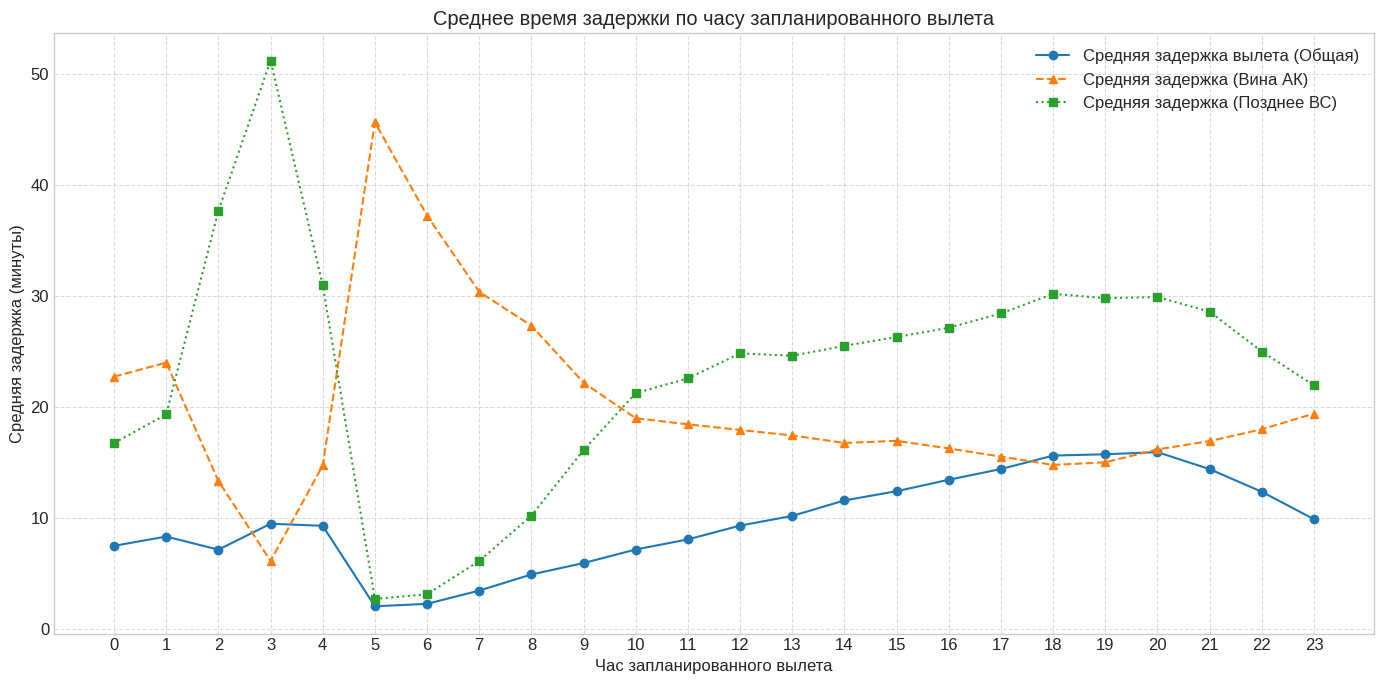

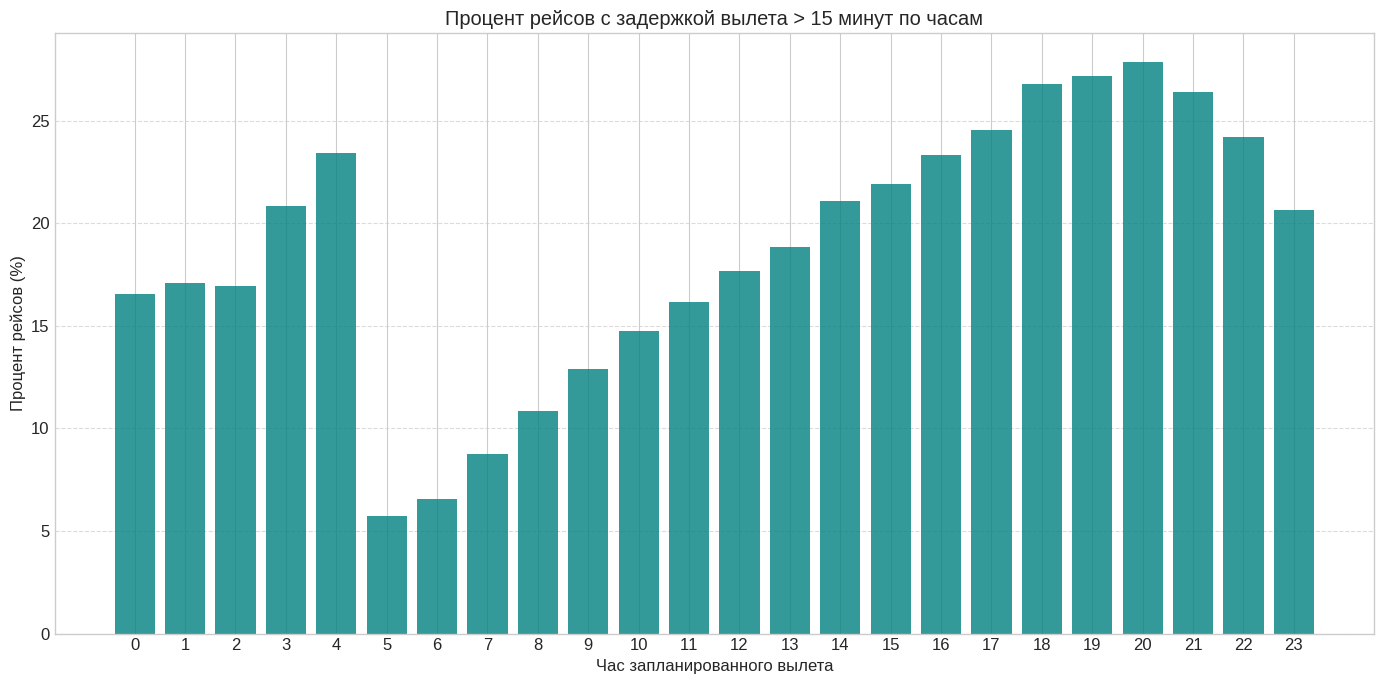

In [27]:
df_hourly = df_flights[['SCHEDULED_DEPARTURE_TIME', 'DEPARTURE_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY']].copy()

df_hourly['SCHEDULED_HOUR'] = pd.to_datetime(df_hourly['SCHEDULED_DEPARTURE_TIME'], format='%H:%M:%S', errors='coerce').dt.hour
df_hourly.dropna(subset=['SCHEDULED_HOUR'], inplace=True)
df_hourly['SCHEDULED_HOUR'] = df_hourly['SCHEDULED_HOUR'].astype(int)

print(f"Данные подготовлены. Проанализировано {len(df_hourly)} рейсов с корректным временем вылета.")

hourly_stats = df_hourly.groupby('SCHEDULED_HOUR').agg(
    avg_dep_delay=('DEPARTURE_DELAY', 'mean'),
    avg_airline_delay=('AIRLINE_DELAY', 'mean'),
    avg_late_aircraft_delay=('LATE_AIRCRAFT_DELAY', 'mean'), # Интересно, а это кто-то читает
    pct_dep_delayed_15min=('DEPARTURE_DELAY', lambda x: (x.dropna() > 15).mean() * 100)
).reset_index()

print("\n--- Почасовая статистика (первые 5 строк) ---")
print(hourly_stats.head())

print("\nСоздание графиков почасовых тенденций...")

plt.figure(figsize=(14, 7))
plt.plot(hourly_stats['SCHEDULED_HOUR'], hourly_stats['avg_dep_delay'], marker='o', linestyle='-', label='Средняя задержка вылета (Общая)')
plt.plot(hourly_stats['SCHEDULED_HOUR'], hourly_stats['avg_airline_delay'].fillna(0), marker='^', linestyle='--', label='Средняя задержка (Вина АК)')
plt.plot(hourly_stats['SCHEDULED_HOUR'], hourly_stats['avg_late_aircraft_delay'].fillna(0), marker='s', linestyle=':', label='Средняя задержка (Позднее ВС)') # fillna(0)

plt.title('Среднее время задержки по часу запланированного вылета')
plt.xlabel('Час запланированного вылета')
plt.ylabel('Средняя задержка (минуты)')
plt.xticks(ticks=np.arange(0, 24, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))
plt.bar(hourly_stats['SCHEDULED_HOUR'], hourly_stats['pct_dep_delayed_15min'], color='teal', alpha=0.8)
plt.title('Процент рейсов с задержкой вылета > 15 минут по часам')
plt.xlabel('Час запланированного вылета')
plt.ylabel('Процент рейсов (%)')
plt.xticks(ticks=np.arange(0, 24, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Выводы по анализу зависимости задержки от времени суток

Анализ средних задержек и частоты значительных задержек (>15 минут) в зависимости от часа запланированного вылета выявил четкую суточную закономерность:

1.  **Накопление задержек в течение дня:** Наблюдается явный цикл:
    * **Минимум:** Средняя задержка вылета достигает минимума (около **2.0 минут**) в **5 утра**. Это время, когда система "перезагружается" перед началом основного дневного трафика.
    * **Рост:** С раннего утра средняя задержка и вероятность значительной задержки начинают неуклонно расти в течение дня.
    * **Пик:** Максимальные значения достигаются вечером. Как **средняя общая задержка вылета (15.9 минут)**, так и **процент рейсов с задержкой > 15 минут (27.9%)** достигают пика в **20:00 (8 часов вечера)**. В это время почти 28% рейсов вылетают со значительной задержкой.
    * **Сохранение:** Высокая вероятность задержек сохраняется и позже вечером (например, в 22:00 все еще 24.2% рейсов задерживаются более чем на 15 минут).

2.  **Причины вечернего пика:** Данные показывают, что основной вклад в пиковую вечернюю задержку вносит **задержка из-за позднего прибытия воздушного судна (`LATE_AIRCRAFT_DELAY`)**. Средняя величина этой задержки (когда она случается) в 20:00 очень высока (около 29.9 мин), что значительно выше среднего значения задержки по вине авиакомпании в тот же час (16.2 мин). Это подтверждает **эффект накопления (каскадный эффект)**: задержки, возникающие в течение дня, передаются от рейса к рейсу и аккумулируются к вечеру.

3.  **Аномалии ранним утром:** Несмотря на общий минимум в 5 утра, наблюдаются интересные всплески *средней величины* конкретных типов задержек в ночные и ранние утренние часы:
    * В **3 часа ночи** средняя задержка из-за **позднего ВС** очень высока (51.2 мин), хотя общая средняя задержка умеренная (9.5 мин). Это может быть связано с последними рейсами предыдущего дня или ночными грузовыми/техническими рейсами.
    * В **5 часов утра**, при минимальной *общей* средней задержке, наблюдается очень высокая средняя задержка по **вине авиакомпании** (45.7 мин). Это может указывать на проблемы с подготовкой первых утренних рейсов (экипажи, предполетная подготовка), которые, хоть и редки, но могут быть очень серьезными. (Это совпадает с выводом изначального примера).

**Рекомендации для Министерства Транспорта:**
* Признать **накопление задержек в течение дня** как ключевую проблему, уделив особое внимание факторам, приводящим к **задержкам из-за позднего прибытия ВС**. Необходимы меры по повышению пунктуальности в течение всего дня и созданию буферов в расписании, особенно для вечерних рейсов.
* Исследовать **причины высоких средних задержек по вине авиакомпаний ранним утром (около 5 утра)**, так как они могут сигнализировать о системных проблемах с началом операционного дня у некоторых перевозчиков.
* Учитывать **высокую вероятность задержек в вечерние часы (после 18:00)** при планировании пропускной способности и информировании пассажиров.



In [29]:
!pip install folium